In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

cwd = Path.cwd().resolve()
repo_root = next((path for path in [cwd, *cwd.parents] if (path / "analogues").is_dir()), None)
if repo_root is None:
    raise FileNotFoundError("Could not find the repo root containing the `analogues` package.")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from analogues import AnalogueSample, FilterConfig, SelectionConfig
from config.loader import load_config

print("Repo root:", repo_root)

def resolve_base_path(repo_root: Path) -> str:
    raw_candidates = [
        os.environ.get("TNG_BASE_PATH"),
        os.environ.get("ILLUSTRIS_BASE_PATH"),
        str(repo_root / "tng300" / "outputs"),
    ]

    for raw in raw_candidates:
        if not raw:
            continue
        base = Path(raw).expanduser()
        for candidate in (base, base / "tng300" / "outputs"):
            if (candidate / "groups_099").exists():
                return str(candidate.resolve())

    raise FileNotFoundError(
        "Could not find a valid TNG outputs directory. Set TNG_BASE_PATH or ILLUSTRIS_BASE_PATH "
        "to the outputs directory, or to a root that contains tng300/outputs."
    )


config_loader = load_config()
analysis_config = config_loader.get_config()

base_path = resolve_base_path(repo_root)
snap = 99
print("Using base_path:", base_path)

selection_config = SelectionConfig(**analysis_config.selection)
filter_config = FilterConfig(**analysis_config.filter)

print("Selection config loaded from config/config.json:")
display(pd.DataFrame([analysis_config.selection]))
print("Filter config loaded from config/config.json:")
display(pd.DataFrame([analysis_config.filter]))
print("Active features in shared config:", list(analysis_config.features))
print("Active target in shared config:", analysis_config.target_name)

analogue_sample = AnalogueSample(
    base_path=base_path,
    selection_config=selection_config,
    filter_config=filter_config,
    verbose=True,
    snap=snap,
    catalog_c_path=os.path.abspath("../tng300/catalog_c/stellar_circs.hdf5")
)

Repo root: /home/dsp/Desktop/dsp_v3/dsp-cosmology
Using base_path: /home/dsp/Desktop/dsp_v3/dsp-cosmology/tng300/outputs
Selection config loaded from config/config.json:


,m_stellar_min,m_stellar_max,r_min,r_max,blue_threshold_gr,disc_threshold
0,2.000000e+10,5.000000e+11,500.0,1000.0,0.65,0.1


Filter config loaded from config/config.json:


,v_tot_min,v_tot_max,vt_min,vt_max,vr_min,vr_max,density_radius,intruder_factor,third_massive_factor
0,0,600,0,300,-400,0,2000,0.5,1.5


Active features in shared config: ['r_kpc', 'v_r', 'v_t', 'k_band_small', 'k_band_large', 'pair_is_red_red']
Active target in shared config: total_virial_mass

[DIAGNOSTIC] Simulation Header Constants
╒════════════╤═══════════╤═══════════════╕
│ Parameter  │ Value     │ Units         │
├────────────┼───────────┼───────────────┤
│ Hubble (h) │ 0.6774    │ dimensionless │
├────────────┼───────────┼───────────────┤
│ Box Side   │ 302627.69 │ kpc           │
╘════════════╧═══════════╧═══════════════╛

[DIAGNOSTIC] Sample Selection
╒═════════════════════════════════════════╤══════════╤═════════════════╕
│ Selection Step                          │    Count │ Yield           │
╞═════════════════════════════════════════╪══════════╪═════════════════╡
│ Total Subhalos in Catalog               │ 14485709 │ 100.0%          │
├─────────────────────────────────────────┼──────────┼─────────────────┤
│ Passed Quality Flags (SubhaloFlag==1)   │  1902558 │ 13.1%           │
├────────────────────────────

<>:91: SyntaxWarning: invalid escape sequence '\m'
<>:91: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_8524/262466244.py:91: SyntaxWarning: invalid escape sequence '\m'
  "$\mathcal{{F}} < 0.5 \wedge \mathcal{{T}}_{{\mathrm{{dom}}}}$": {


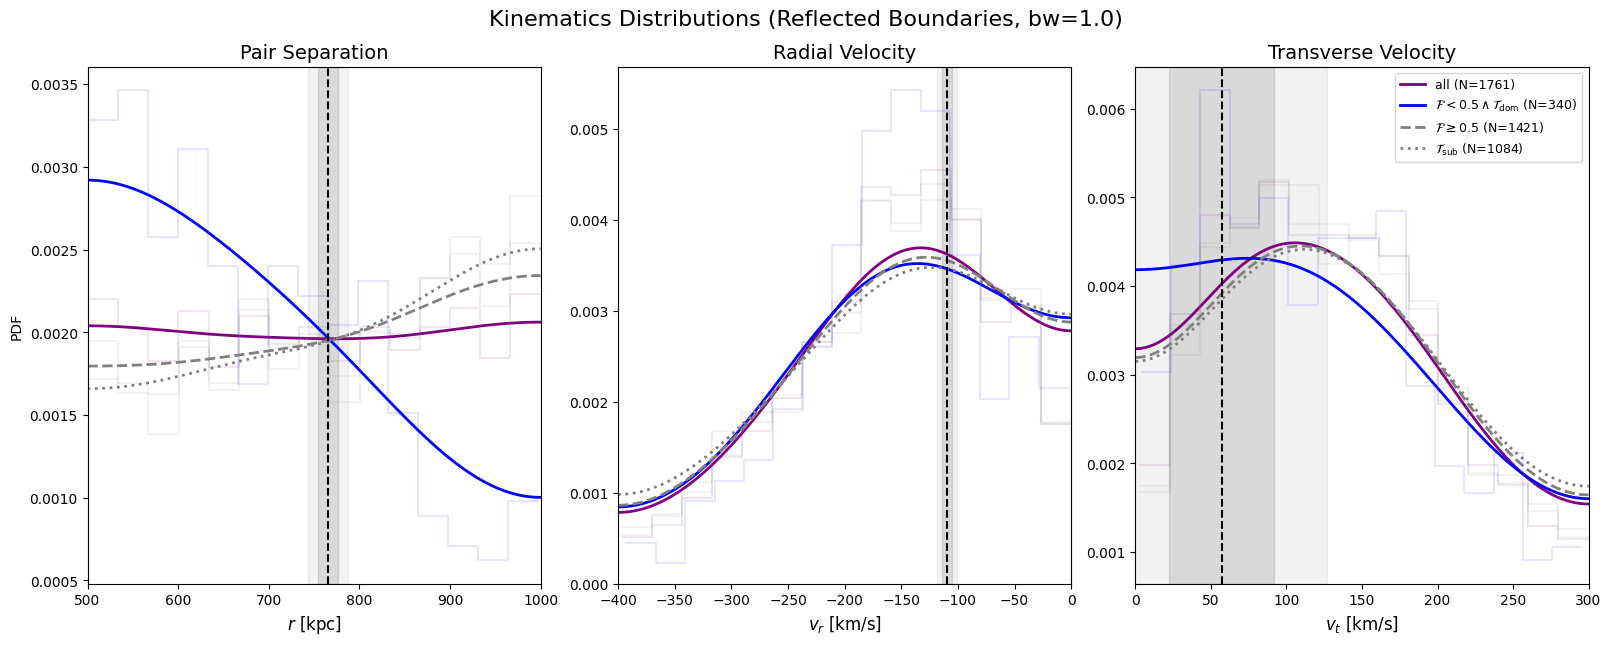

In [9]:
from typing import Any
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import gaussian_kde

def _reflected_kde(ax, data, boundary, color, label=None, ls='-', bw_adjust=1.0, lw=2):
    """
    Computes and plots a KDE using boundary reflection to avoid edge dipping.
    """
    low, high = boundary
    
    ghost_low = 2 * low - data
    ghost_high = 2 * high - data
    combined = np.concatenate([data, ghost_low, ghost_high])
    
    kde = gaussian_kde(combined)
    kde.set_bandwidth(bw_method=kde.factor * bw_adjust)
    
    x_grid = np.linspace(low, high, 200)
    density = kde(x_grid) * 3
    
    ax.plot(x_grid, density, color=color, linestyle=ls, label=label, linewidth=lw)

def kinematics_distributions(analogue_sample, selection_config, filter_config, categories, **kwargs):
    obs_data = {
        'r':  {'val': 765, 'sigma': 11, 'label': "Pair Separation", 'unit': "$r$ [kpc]"},
        'vr': {'val': -109.3, 'sigma': 4.4, 'label': "Radial Velocity", 'unit': "$v_r$ [km/s]"},
        'vt': {'val': 57, 'sigma': 35, 'label': "Transverse Velocity", 'unit': "$v_t$ [km/s]"}
    }

    bw = kwargs.get("bw_distributions", 1.0)
    dist, vr, vt = analogue_sample.pairs.separation, analogue_sample.pairs.vr, analogue_sample.pairs.vt
    
    ranges = {
        'r':  [selection_config.r_min, selection_config.r_max],
        'vr': [filter_config.vr_min, filter_config.vr_max],
        'vt': [filter_config.vt_min, filter_config.vt_max]
    }

    figsize = kwargs.get("figsize_distributions", (16, 6))
    fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)

    for i, (key, info) in enumerate(obs_data.items()):
        ax = axes[i]
        limit = ranges[key]
        raw_data = [dist, vr, vt][i]
        
        sns.histplot(raw_data, ax=ax, color="purple", element="step", 
                     fill=False, stat="density", alpha=0.1, bins=15, label=None)
        _reflected_kde(ax, raw_data, limit, "purple", 
                       label=f'all (N={len(raw_data)})', bw_adjust=bw)

        for label, config in categories.items():
            mask = config['mask']
            style = config.get('style', {})
            
            cat_data = [dist[mask], vr[mask], vt[mask]][i]

            if len(cat_data) < 2:
                continue
                
            color = style.get('color', 'black')
            ls = style.get('ls', '-')

            sns.histplot(cat_data, ax=ax, color=color, element="step", 
                         fill=False, stat="density", alpha=0.1, bins=15, label=None)
            
            _reflected_kde(ax, cat_data, limit, color, 
                           label=f'{label} (N={len(cat_data)})', ls=ls, bw_adjust=bw)

        mu, std = info['val'], info['sigma']
        ax.axvspan(mu - 2*std, mu + 2*std, color='black', alpha=0.05)
        ax.axvspan(mu - std, mu + std, color='black', alpha=0.1)
        ax.axvline(mu, color='black', linestyle='--', linewidth=1.5)
        
        ax.set_xlim(limit)
        ax.set_title(info['label'], fontsize=14)
        ax.set_xlabel(info['unit'], fontsize=12)
        ax.set_ylabel("PDF" if i == 0 else "")

    axes[2].legend(loc='upper right', fontsize=9, frameon=True)
    fig.suptitle(f"Kinematics Distributions (Reflected Boundaries, bw={bw})", fontsize=16, y=1.05)

    return fig

perturbed = analogue_sample.pairs.force_ratio >= 0.5
tidally_subdominant = ~analogue_sample.pairs.is_tidally_dominant

categories = {
    "$\mathcal{{F}} < 0.5 \wedge \mathcal{{T}}_{{\mathrm{{dom}}}}$": {
        "mask": ~perturbed & ~tidally_subdominant,
        "style": {'color': 'blue', 'ls': '-'}
    },
    r"$\mathcal{{F}} \geq 0.5$": {
        "mask": perturbed,
        "style": {'color': 'gray', 'ls': '--'}
    }, 
    r"$\mathcal{{T}}_{{\mathrm{{sub}}}}$": {
        "mask": tidally_subdominant,
        "style": {'color': 'gray', 'ls': ':'}
    }
}

plots = kinematics_distributions(analogue_sample, selection_config, filter_config, categories)